In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model18_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model18_0)
describe(model18_0)

MACs: 4.28 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model18_0.pt
Starting
Epoch 1/60: Train loss = 1.1030, Train accuracy = 0.6083, Test loss = 1.0729, Test accuracy = 0.6242
Epoch 2/60: Train loss = 0.9203, Train accuracy = 0.6776, Test loss = 0.9298, Test accuracy = 0.6783
Epoch 3/60: Train loss = 0.7907, Train accuracy = 0.7191, Test loss = 0.7848, Test accuracy = 0.7261
Epoch 4/60: Train loss = 0.7335, Train accuracy = 0.7427, Test loss = 0.7664, Test accuracy = 0.7388
Epoch 5/60: Train loss = 0.6968, Train accuracy = 0.7572, Test loss = 0.7451, Test accuracy = 0.7501
Epoch 6/60: Train loss = 0.6651, Train accuracy = 0.7660, Test loss = 0.7043, Test accuracy = 0.7584
Epoch 7/60: Train loss = 0.5796, Train accuracy = 0.7965, Test loss = 0.6194, Test accuracy = 0.7934
Epoch 8/60: Train loss = 0.6047, Train accuracy = 0.7881, Test loss = 0.6199, Test accuracy = 0.7851
Epoch 9/60: Train loss = 0.5860, Train accuracy = 0.7918, Test loss = 0.6195, Test accuracy = 0.7864
Epoch 10/60: Train loss = 0.565

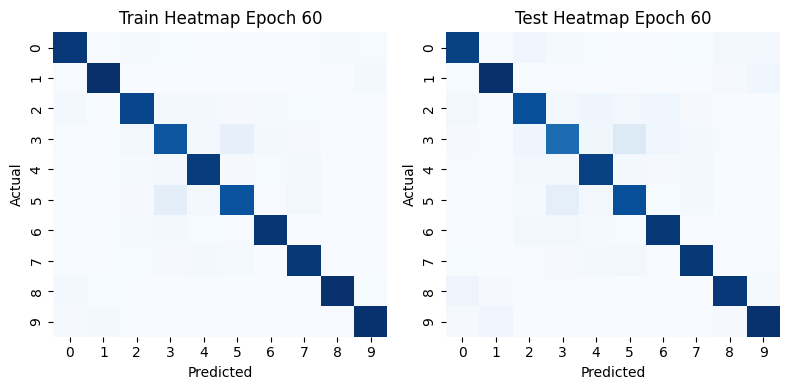

<Figure size 1200x600 with 0 Axes>

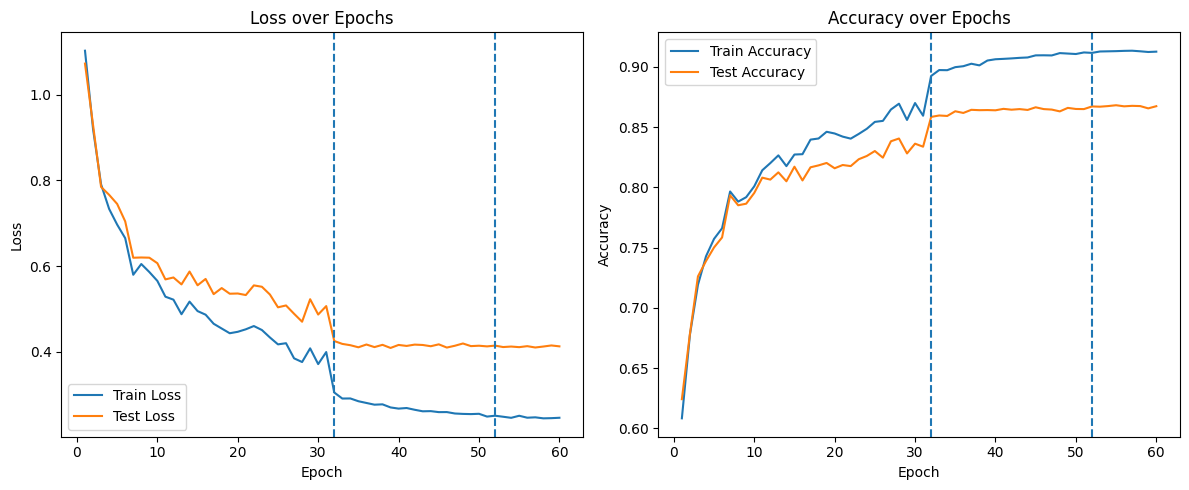

In [6]:
trainf32(model18_0,"model_weights/model18_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model18_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model18_1)
describe(model18_1)

MACs: 4.28 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Starting


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 1/60: Train loss = 1.1009, Train accuracy = 0.6099, Test loss = 1.1220, Test accuracy = 0.6130
Epoch 2/60: Train loss = 0.8288, Train accuracy = 0.7094, Test loss = 0.8151, Test accuracy = 0.7092
Epoch 3/60: Train loss = 0.7550, Train accuracy = 0.7403, Test loss = 0.7664, Test accuracy = 0.7450
Epoch 4/60: Train loss = 0.9098, Train accuracy = 0.6953, Test loss = 0.9308, Test accuracy = 0.6895
Epoch 5/60: Train loss = 0.6470, Train accuracy = 0.7745, Test loss = 0.6589, Test accuracy = 0.7765
Epoch 6/60: Train loss = 0.5740, Train accuracy = 0.8029, Test loss = 0.5976, Test accuracy = 0.7978
Epoch 7/60: Train loss = 0.5366, Train accuracy = 0.8138, Test loss = 0.5786, Test accuracy = 0.8018
Epoch 8/60: Train loss = 0.5495, Train accuracy = 0.8089, Test loss = 0.5866, Test accuracy = 0.8017
Epoch 9/60: Train loss = 0.5850, Train accuracy = 0.7975, Test loss = 0.6269, Test accuracy = 0.7867
Epoch 10/60: Train loss = 0.5066, Train accuracy = 0.8242, Test loss = 0.5480, Test accurac

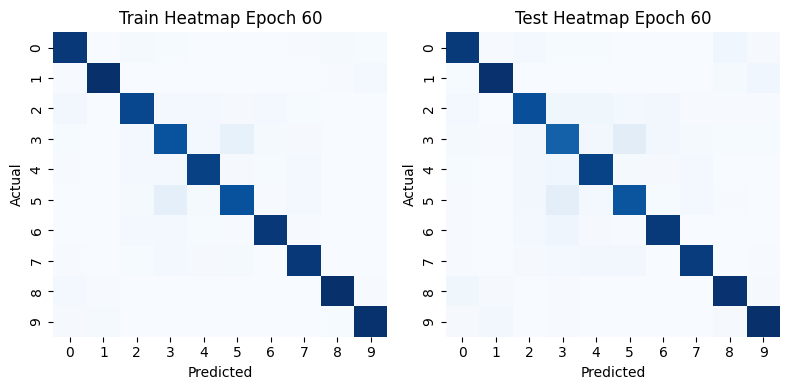

<Figure size 1200x600 with 0 Axes>

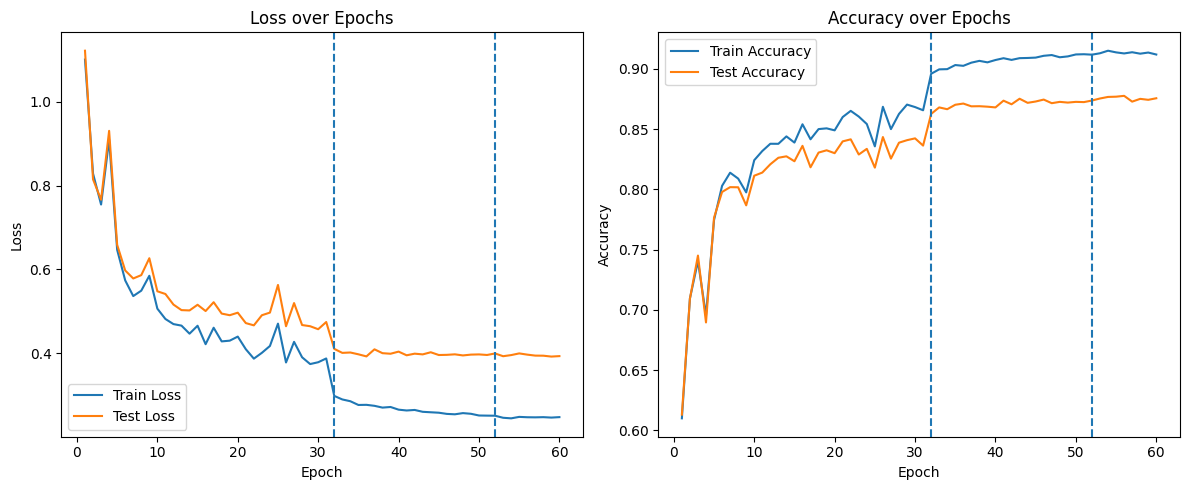

In [8]:
trainf32(model18_1,"model_weights/model18_1.pt",criterion,train_dataset,val_dataset, batch_size=64)